<a href="https://colab.research.google.com/github/jiho1332/daython-energy-analysis/blob/main/%EB%8D%B0%EC%9D%B4%ED%86%A4%EA%B3%B5%EB%AA%A8%EC%A0%84%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/데이톤 공모전/rtu_data_full.csv'

In [ ]:
import pandas as pd

df_sample = pd.read_csv(file_path, nrows=1000)
print(df_sample.shape)
print(df_sample.dtypes)
df_sample.head()

(1000, 19)
module(equipment)        object
timestamp                 int64
localtime                 int64
operation                 int64
voltageR                float64
voltageS                float64
voltageT                float64
voltageRS               float64
voltageST               float64
voltageTR               float64
currentR                float64
currentS                float64
currentT                float64
activePower             float64
powerFactorR            float64
powerFactorS            float64
powerFactorT            float64
reactivePowerLagging    float64
accumActiveEnergy         int64
dtype: object


,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
0,1(PM-3),1733040000000,20241201000000,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004
1,1(PM-3),1733040005000,20241201000005,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008
2,1(PM-3),1733040010000,20241201000010,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011
3,1(PM-3),1733040015000,20241201000015,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016
4,1(PM-3),1733040020000,20241201000020,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020


In [ ]:
import pandas as pd

# 설비 종류가 몇 개인지 확인 (일부만 읽어서)
sample = pd.read_csv(file_path, nrows=100000)
print(sample['module(equipment)'].unique())
print(sample['module(equipment)'].nunique())

# 전체 행 수만 빠르게 세기 (메모리 안 씀)
with open(file_path) as f:
    total_rows = sum(1 for _ in f) - 1
print(f"전체 행 수: {total_rows:,}")

['1(PM-3)']
1
전체 행 수: 33,696,013


In [ ]:
import pandas as pd

chunksize = 2_000_000
parquet_path = '/content/drive/MyDrive/데이톤 공모전/rtu_data_full.parquet'

chunks = []
for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunksize)):
    # timestamp를 datetime으로 변환
    chunk['datetime'] = pd.to_datetime(chunk['localtime'], format='%Y%m%d%H%M%S')
    chunks.append(chunk)
    print(f"chunk {i} 처리 완료: {len(chunk)}행")

df = pd.concat(chunks, ignore_index=True)
df.to_parquet(parquet_path, index=False)
print("저장 완료:", df.shape)

chunk 0 처리 완료: 2000000행
chunk 1 처리 완료: 2000000행
chunk 2 처리 완료: 2000000행
chunk 3 처리 완료: 2000000행
chunk 4 처리 완료: 2000000행
chunk 5 처리 완료: 2000000행
chunk 6 처리 완료: 2000000행
chunk 7 처리 완료: 2000000행
chunk 8 처리 완료: 2000000행
chunk 9 처리 완료: 2000000행
chunk 10 처리 완료: 2000000행
chunk 11 처리 완료: 2000000행
chunk 12 처리 완료: 2000000행
chunk 13 처리 완료: 2000000행
chunk 14 처리 완료: 2000000행
chunk 15 처리 완료: 2000000행
chunk 16 처리 완료: 1696013행
저장 완료: (33696013, 20)


In [ ]:
equipment_set = set()

for chunk in pd.read_csv(file_path, usecols=['module(equipment)'], chunksize=2_000_000):
    equipment_set.update(chunk['module(equipment)'].unique())

print(equipment_set)
print(len(equipment_set))

{'1(PM-3)', '13(3호기)', '16(호이스트)', '4(분쇄기(1))', '11(우측분전반1)', '14(2호기)', '15(예비건조기)', '18(우측분전반2)', '17(6호기)', '2(L-1전등)', '12(4호기)', '5(좌측분전반)', '3(분쇄기(2))'}
13


In [ ]:
# 설비별로 데이터가 몇 행씩 있고, 시간 범위가 어떻게 되는지 확인
equipment_summary = []

for chunk in pd.read_csv(file_path, usecols=['module(equipment)', 'localtime'], chunksize=2_000_000):
    g = chunk.groupby('module(equipment)')['localtime'].agg(['count', 'min', 'max'])
    equipment_summary.append(g)

result = pd.concat(equipment_summary)
final_summary = result.groupby(result.index).agg({
    'count': 'sum',
    'min': 'min',
    'max': 'max'
})
print(final_summary)

                     count             min             max
module(equipment)                                         
1(PM-3)            2592001  20241201000000  20250430000000
11(우측분전반1)         2592001  20241201000000  20250430000000
12(4호기)            2592001  20241201000000  20250430000000
13(3호기)            2592001  20241201000000  20250430000000
14(2호기)            2592001  20241201000000  20250430000000
15(예비건조기)          2592001  20241201000000  20250430000000
16(호이스트)           2592001  20241201000000  20250430000000
17(6호기)            2592001  20241201000000  20250430000000
18(우측분전반2)         2592001  20241201000000  20250430000000
2(L-1전등)           2592001  20241201000000  20250430000000
3(분쇄기(2))          2592001  20241201000000  20250430000000
4(분쇄기(1))          2592001  20241201000000  20250430000000
5(좌측분전반)           2592001  20241201000000  20250430000000


In [ ]:
# 1. 판다스 불러오기
import pandas as pd

In [ ]:
# 2. 드라이브 마운트 (이미 마운트 됐다는 메시지 뜨면 정상)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3. Parquet 파일 불러오기
parquet_path = '/content/drive/MyDrive/데이톤 공모전/rtu_data_full.parquet'
df = pd.read_parquet(parquet_path)
print(df.shape)
df.head()

(33696013, 20)


,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy,datetime
0,1(PM-3),1733040000000,20241201000000,1,214.38,214.45,219.10,371.37,375.45,375.39,15.16,15.53,20.65,2961.61,87.31,99.71,89.45,785.37,1955004,2024-12-01 00:00:00
1,1(PM-3),1733040005000,20241201000005,1,214.05,211.74,218.68,368.73,372.74,374.74,25.70,7.07,19.75,3017.48,87.54,87.67,94.17,376.57,1955008,2024-12-01 00:00:05
2,1(PM-3),1733040010000,20241201000010,1,215.79,214.92,211.10,373.00,368.94,369.69,13.64,14.87,13.70,2408.01,85.46,99.00,94.45,296.08,1955011,2024-12-01 00:00:10
3,1(PM-3),1733040015000,20241201000015,1,210.39,214.92,215.57,368.32,372.80,368.89,25.76,26.35,5.80,3289.33,85.24,99.53,95.61,488.48,1955016,2024-12-01 00:00:15
4,1(PM-3),1733040020000,20241201000020,1,216.71,216.37,215.65,375.05,374.13,374.43,8.65,29.49,15.09,3069.31,92.81,91.26,91.82,604.70,1955020,2024-12-01 00:00:20


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 22.1 MB/s eta 0:00:00


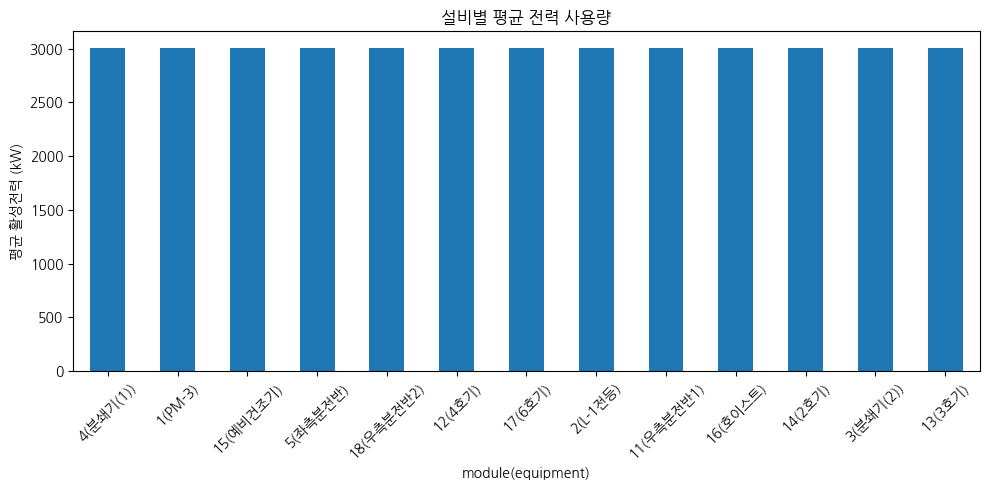

module(equipment)
4(분쇄기(1))     3010.729388
1(PM-3)       3010.413633
15(예비건조기)     3010.408632
5(좌측분전반)      3010.259966
18(우측분전반2)    3010.046483
12(4호기)       3010.032707
17(6호기)       3009.942371
2(L-1전등)      3009.914799
11(우측분전반1)    3009.911702
16(호이스트)      3009.765152
14(2호기)       3009.700472
3(분쇄기(2))     3009.570051
13(3호기)       3008.683028
Name: activePower, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지 (Colab에서 한글 폰트 설치)
!pip install -q koreanize-matplotlib
import koreanize_matplotlib

# 설비별로 묶어서 activePower(유효전력) 평균 계산
equip_avg = df.groupby('module(equipment)')['activePower'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
equip_avg.plot(kind='bar')
plt.title('설비별 평균 전력 사용량')
plt.ylabel('평균 활성전력 (kW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(equip_avg)

In [ ]:
equip_stats = df.groupby('module(equipment)')['activePower'].agg(['mean','std','min','max'])
print(equip_stats)

                          mean         std     min      max
module(equipment)                                          
1(PM-3)            3010.413633  716.716297  880.88  5184.14
11(우측분전반1)         3009.911702  717.175406  878.54  5220.93
12(4호기)            3010.032707  717.540003  874.71  5209.82
13(3호기)            3008.683028  716.955980  868.43  5219.73
14(2호기)            3009.700472  716.963084  871.28  5193.97
15(예비건조기)          3010.408632  717.035831  878.11  5213.06
16(호이스트)           3009.765152  717.411093  882.67  5192.98
17(6호기)            3009.942371  716.942727  872.88  5184.32
18(우측분전반2)         3010.046483  717.124029  873.62  5195.08
2(L-1전등)           3009.914799  717.343771  873.87  5188.85
3(분쇄기(2))          3009.570051  716.899373  870.97  5171.16
4(분쇄기(1))          3010.729388  717.039418  873.63  5207.16
5(좌측분전반)           3010.259966  717.742185  864.44  5175.69


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
parquet_path = '/content/drive/MyDrive/데이톤 공모전/rtu_data_full.parquet'

cols_needed = ['module(equipment)', 'datetime', 'operation', 'activePower',
               'powerFactorR', 'powerFactorS', 'powerFactorT', 'accumActiveEnergy']
df = pd.read_parquet(parquet_path, columns=cols_needed)

for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

print(df.shape)
print(df.memory_usage(deep=True).sum() / 1024**3, "GB")

(33696013, 8)
3.7803069669753313 GB


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

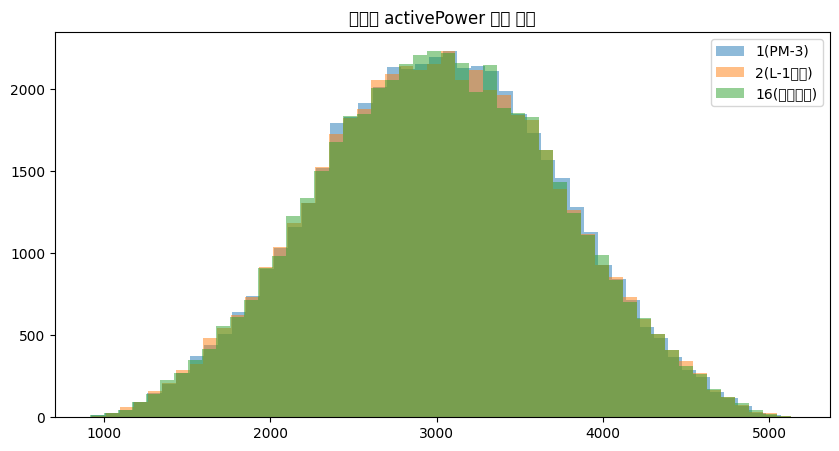

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for eq in ['1(PM-3)', '2(L-1전등)', '16(호이스트)']:
    subset = df.loc[df['module(equipment)'] == eq, 'activePower'].sample(n=50000, random_state=1)
    plt.hist(subset, bins=50, alpha=0.5, label=eq)

plt.legend()
plt.title('설비별 activePower 분포 비교')
plt.show()

In [ ]:
# ① 설비별 activePower 평균/표준편차/범위
equip_stats = df.groupby('module(equipment)')['activePower'].agg(['mean','std','min','max'])
print(equip_stats)

                          mean         std         min          max
module(equipment)                                                  
1(PM-3)            3010.413574  716.716309  880.880005  5184.140137
11(우측분전반1)         3009.911621  717.175415  878.539978  5220.930176
12(4호기)            3010.032715  717.539978  874.710022  5209.819824
13(3호기)            3008.683105  716.955994  868.429993  5219.729980
14(2호기)            3009.700684  716.963074  871.280029  5193.970215
15(예비건조기)          3010.408691  717.035828  878.109985  5213.060059
16(호이스트)           3009.765137  717.411072  882.669983  5192.979980
17(6호기)            3009.942383  716.942749  872.880005  5184.319824
18(우측분전반2)         3010.046387  717.124023  873.619995  5195.080078
2(L-1전등)           3009.914795  717.343750  873.869995  5188.850098
3(분쇄기(2))          3009.570068  716.899353  870.969971  5171.160156
4(분쇄기(1))          3010.729248  717.039429  873.630005  5207.160156
5(좌측분전반)           3010.260010  717.742188  864.

In [ ]:
# ② 누적 전력량 증가폭 - 이게 진짜 사용량을 반영할 가능성이 높음
energy_range = df.groupby('module(equipment)')['accumActiveEnergy'].agg(lambda x: x.max()-x.min())
print(energy_range.sort_values(ascending=False))

module(equipment)
4(분쇄기(1))     10838626
1(PM-3)       10837489
15(예비건조기)     10837471
5(좌측분전반)      10836936
18(우측분전반2)    10836167
12(4호기)       10836119
17(6호기)       10835793
2(L-1전등)      10835695
11(우측분전반1)    10835682
16(호이스트)      10835157
14(2호기)       10834922
3(분쇄기(2))     10834452
13(3호기)       10831258
Name: accumActiveEnergy, dtype: int64


In [ ]:
# ③ operation(가동상태) 패턴이 설비별로 다른지
op_pattern = df.groupby('module(equipment)')['operation'].mean()  # 가동 비율
print(op_pattern.sort_values(ascending=False))

module(equipment)
1(PM-3)       1.0
11(우측분전반1)    1.0
12(4호기)       1.0
13(3호기)       1.0
14(2호기)       1.0
15(예비건조기)     1.0
16(호이스트)      1.0
17(6호기)       1.0
18(우측분전반2)    1.0
2(L-1전등)      1.0
3(분쇄기(2))     1.0
4(분쇄기(1))     1.0
5(좌측분전반)      1.0
Name: operation, dtype: float64


In [ ]:
# ④ 역률(powerFactor)이 설비별로 다른지 - 이게 다르면 비효율 분석의 좋은 축이 됨
pf_stats = df.groupby('module(equipment)')[['powerFactorR','powerFactorS','powerFactorT']].mean()
print(pf_stats)

                   powerFactorR  powerFactorS  powerFactorT
module(equipment)                                          
1(PM-3)               92.502869     92.503281     92.496429
11(우측분전반1)            92.503677     92.505302     92.503731
12(4호기)               92.498779     92.503510     92.500679
13(3호기)               92.500443     92.504501     92.501030
14(2호기)               92.499710     92.501511     92.494888
15(예비건조기)             92.242813     92.245850     92.254738
16(호이스트)              92.496658     92.501091     92.497459
17(6호기)               92.350349     92.351425     92.346390
18(우측분전반2)            92.500465     92.499504     92.502655
2(L-1전등)              92.495247     92.501579     92.499023
3(분쇄기(2))             92.504745     92.493454     92.498856
4(분쇄기(1))             92.500839     92.500046     92.499283
5(좌측분전반)              92.498108     92.499451     92.499779


In [ ]:
# ③ 가동 비율 (operation=1인 비율)
op_pattern = df.groupby('module(equipment)')['operation'].mean()
print(op_pattern.sort_values(ascending=False))

module(equipment)
1(PM-3)       1.0
11(우측분전반1)    1.0
12(4호기)       1.0
13(3호기)       1.0
14(2호기)       1.0
15(예비건조기)     1.0
16(호이스트)      1.0
17(6호기)       1.0
18(우측분전반2)    1.0
2(L-1전등)      1.0
3(분쇄기(2))     1.0
4(분쇄기(1))     1.0
5(좌측분전반)      1.0
Name: operation, dtype: float64


In [ ]:
pf_stats = df.groupby('module(equipment)')[['powerFactorR','powerFactorS','powerFactorT']].agg(['mean','std'])
print(pf_stats)

                  powerFactorR           powerFactorS           powerFactorT  \
                          mean       std         mean       std         mean   
module(equipment)                                                              
1(PM-3)              92.502869  4.330089    92.503281  4.331203    92.496429   
11(우측분전반1)           92.503677  4.330271    92.505302  4.330080    92.503731   
12(4호기)              92.498779  4.331606    92.503510  4.329668    92.500679   
13(3호기)              92.500443  4.330916    92.504501  4.331931    92.501030   
14(2호기)              92.499710  4.332705    92.501511  4.329061    92.494888   
15(예비건조기)            92.242813  5.002582    92.245850  5.001352    92.254738   
16(호이스트)             92.496658  4.329489    92.501091  4.328398    92.497459   
17(6호기)              92.350349  4.575544    92.351425  4.580716    92.346390   
18(우측분전반2)           92.500465  4.329718    92.499504  4.329454    92.502655   
2(L-1전등)             92.495247  4.330486

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

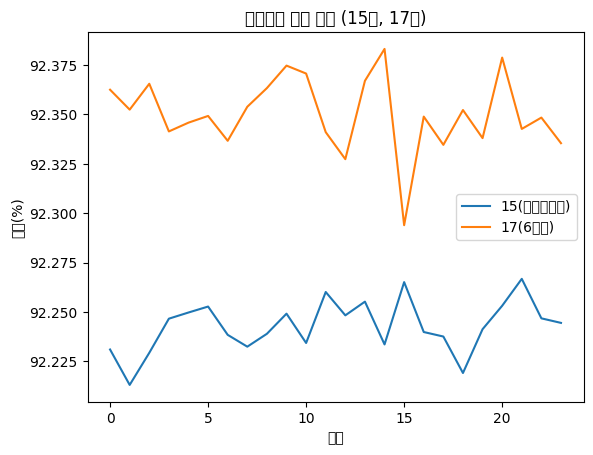

In [ ]:
for eq in ['15(예비건조기)', '17(6호기)']:
    subset = df[df['module(equipment)'] == eq].copy()
    subset['hour'] = subset['datetime'].dt.hour
    hourly_pf = subset.groupby('hour')['powerFactorR'].mean()
    plt.plot(hourly_pf, label=eq)

plt.legend()
plt.title('시간대별 평균 역률 (15번, 17번)')
plt.xlabel('시간')
plt.ylabel('역률(%)')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

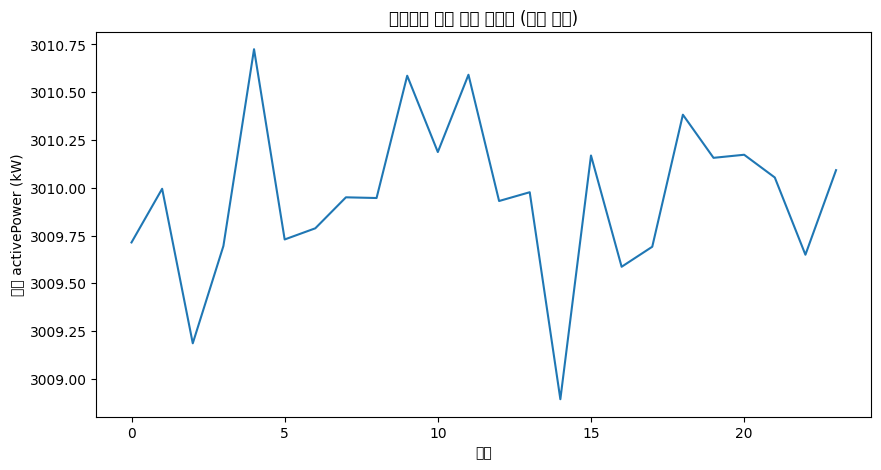

In [ ]:
df['hour'] = df['datetime'].dt.hour
hourly_power = df.groupby('hour')['activePower'].mean()

plt.figure(figsize=(10,5))
hourly_power.plot()
plt.title('시간대별 평균 전력 사용량 (전체 설비)')
plt.xlabel('시간')
plt.ylabel('평균 activePower (kW)')
plt.show()

In [ ]:
df['month'] = df['datetime'].dt.month
monthly_power = df.groupby('month')['activePower'].mean()
print(monthly_power)

month
1     3010.029297
2     3010.239502
3     3010.010498
4     3009.855469
12    3009.648193
Name: activePower, dtype: float32


In [ ]:
df2 = pd.read_parquet(parquet_path, columns=['module(equipment)','voltageR','voltageS','voltageT'])
imbalance = df2.groupby('module(equipment)').apply(
    lambda x: (x[['voltageR','voltageS','voltageT']].std(axis=1)).mean()
)
print(imbalance.sort_values(ascending=False))

module(equipment)
13(3호기)       2.637765
3(분쇄기(2))     2.633372
1(PM-3)       2.633243
11(우측분전반1)    2.633206
15(예비건조기)     2.633160
17(6호기)       2.633089
14(2호기)       2.633014
4(분쇄기(1))     2.632705
5(좌측분전반)      2.632299
12(4호기)       2.632168
18(우측분전반2)    2.631971
2(L-1전등)      2.631661
16(호이스트)      2.631294
dtype: float64


/tmp/ipykernel_4957/2717154444.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  imbalance = df2.groupby('module(equipment)').apply(


In [ ]:
# 역률이 심하게 낮은 순간들 추출
low_pf = df[(df['powerFactorR'] < 80) | (df['powerFactorS'] < 80) | (df['powerFactorT'] < 80)]
print(len(low_pf))
print(low_pf['module(equipment)'].value_counts())
print(low_pf[['datetime','module(equipment)','powerFactorR']].sort_values('datetime').head(20))

50936
module(equipment)
15(예비건조기)    26244
17(6호기)      24692
Name: count, dtype: int64
                    datetime module(equipment)  powerFactorR
28512012 2024-12-01 00:00:05           17(6호기)     79.139999
23328017 2024-12-01 00:00:40         15(예비건조기)     70.650002
28512024 2024-12-01 00:01:05           17(6호기)     70.110001
23328071 2024-12-01 00:05:10         15(예비건조기)     66.379997
23328096 2024-12-01 00:07:15         15(예비건조기)     64.160004
23328235 2024-12-01 00:18:50         15(예비건조기)     66.120003
28512268 2024-12-01 00:21:25           17(6호기)     78.230003
28512339 2024-12-01 00:27:20           17(6호기)     76.739998
28512395 2024-12-01 00:32:00           17(6호기)     80.239998
28512480 2024-12-01 00:39:05           17(6호기)     74.559998
28512577 2024-12-01 00:47:10           17(6호기)     82.779999
23328603 2024-12-01 00:49:30         15(예비건조기)     74.809998
28512609 2024-12-01 00:49:50           17(6호기)     81.209999
23328663 2024-12-01 00:54:30         15(예비건조기)     74.2500

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

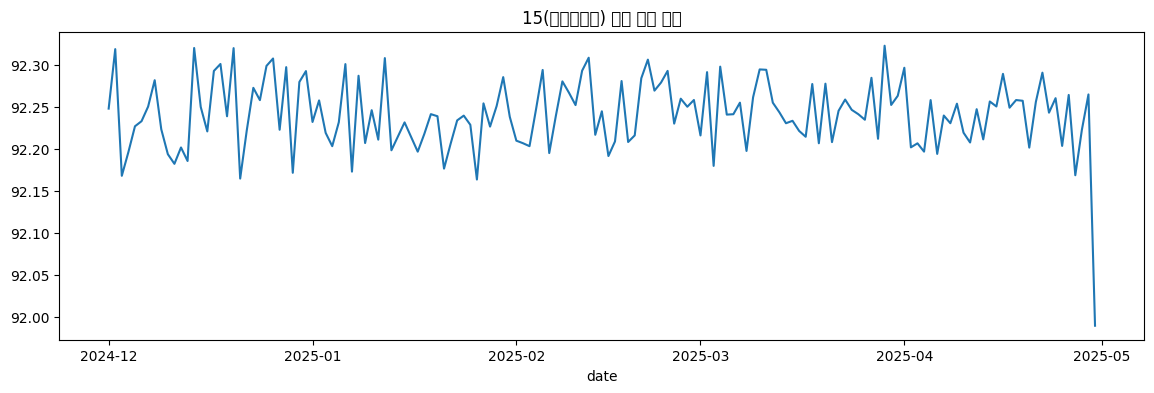

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

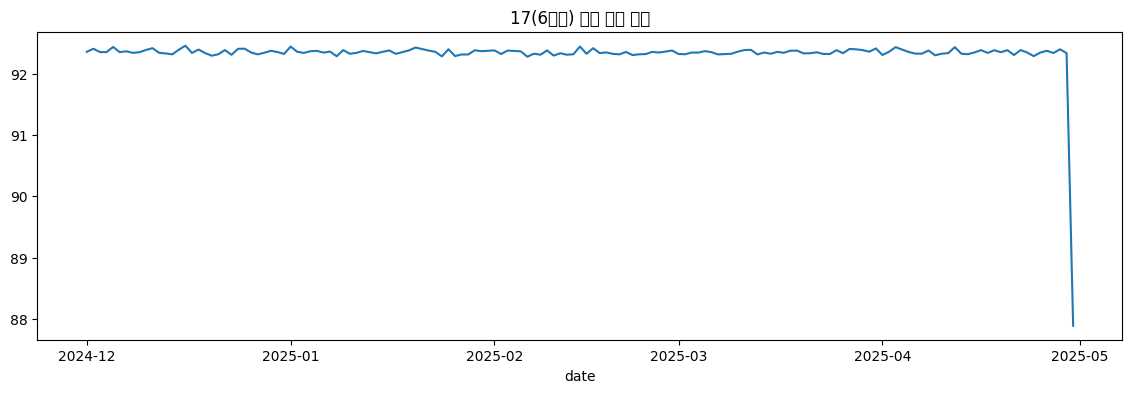

In [ ]:

for eq in ['15(예비건조기)', '17(6호기)']:
    subset = df[df['module(equipment)']==eq].copy()
    subset['date'] = subset['datetime'].dt.date
    daily_pf = subset.groupby('date')['powerFactorR'].mean()
    daily_pf.plot(figsize=(14,4), title=f'{eq} 일별 평균 역률')
    plt.show()

/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


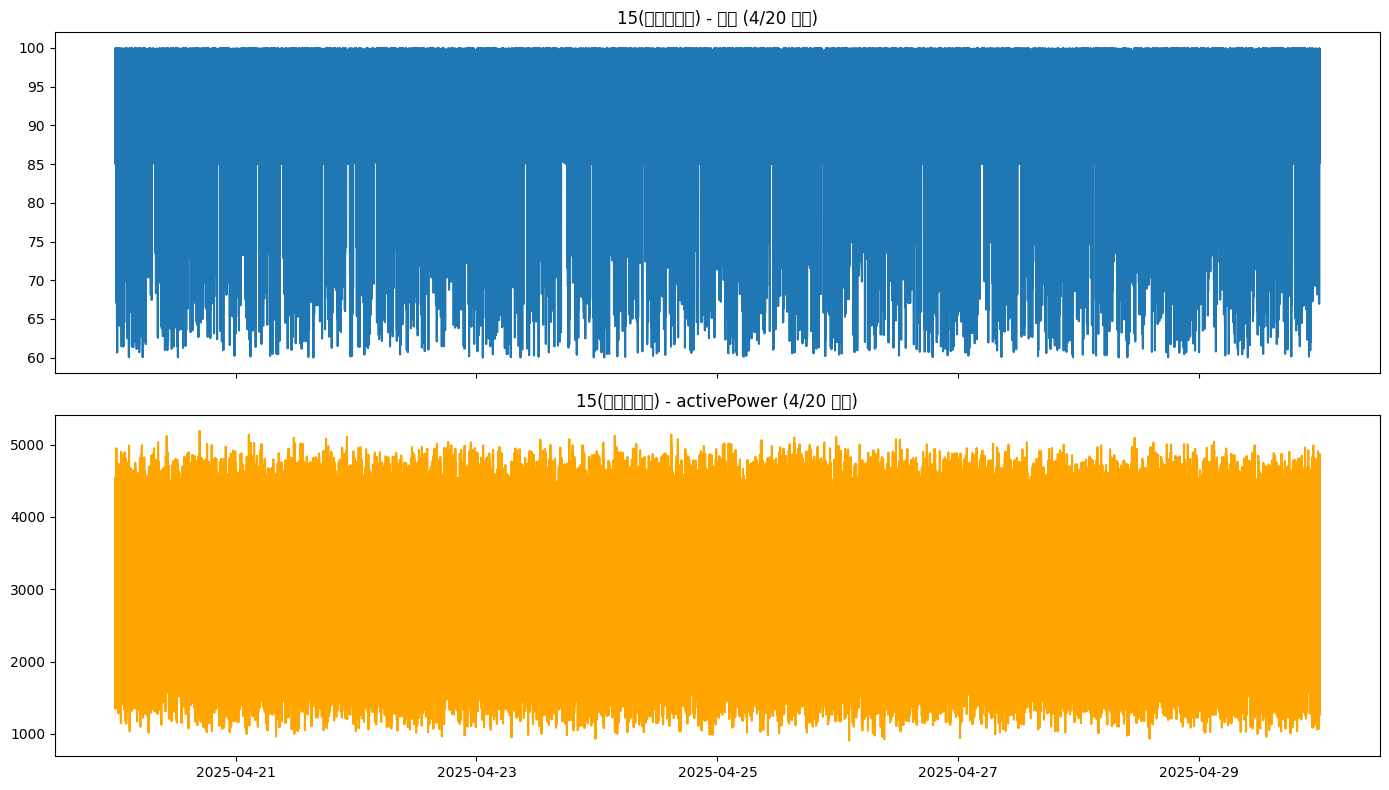

/tmp/ipykernel_4957/409101348.py:13: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


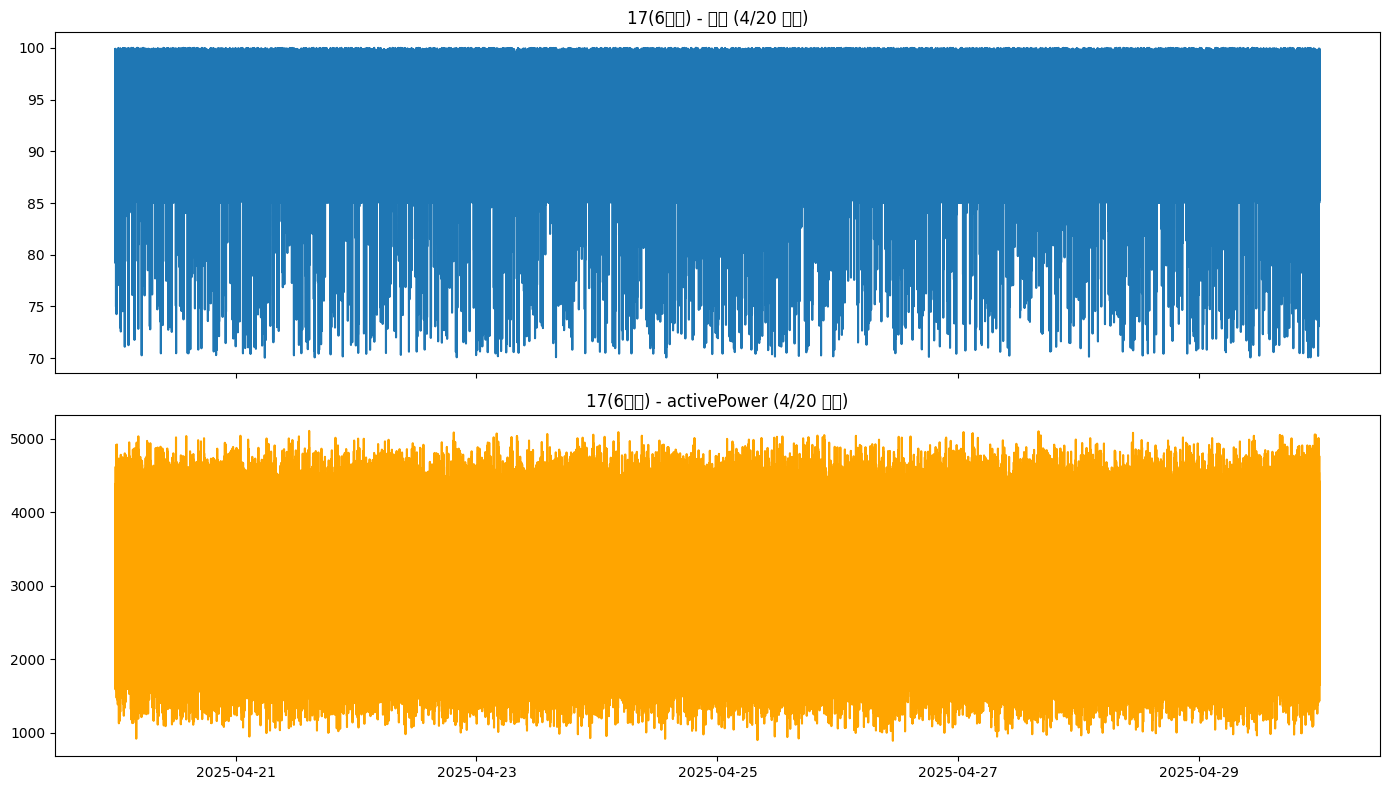

In [ ]:
# 4월 마지막 주만 따로 뽑아서 상세 확인
for eq in ['15(예비건조기)', '17(6호기)']:
    subset = df[(df['module(equipment)']==eq) & (df['datetime'] >= '2025-04-20')].copy()
    subset = subset.sort_values('datetime')

    fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)
    axes[0].plot(subset['datetime'], subset['powerFactorR'])
    axes[0].set_title(f'{eq} - 역률 (4/20 이후)')

    axes[1].plot(subset['datetime'], subset['activePower'], color='orange')
    axes[1].set_title(f'{eq} - activePower (4/20 이후)')

    plt.tight_layout()
    plt.show()